# Daily complaint volume - 90-day forecast

> A model that fits the *decision*, not just the data.

## What this is for

This forecast feeds three different operational decisions, each with a
different horizon and a different cost profile:

| Consumer | Horizon | What they do with it |
|---|---|---|
| Triage lead | 1–7 days | Intra-week shift balancing, queue sizing |
| Rostering | 2–6 weeks | Contractor top-ups, leave approval |
| Capacity planning | 1–3 months | Hiring signals, budget conversations |

The cost of getting it wrong is **asymmetric**: under-forecasting causes
backlog, which itself generates more complaints (a feedback loop), while
over-forecasting wastes some FTE-days. We therefore output a **P50 point
forecast plus an 80% prediction interval**, and tell consumers to plan
to the upper bound for under-staffing-sensitive decisions.

## Success criteria (agreed before modelling)

1. The candidate model must beat **all three** baselines on a 90-day hold-out.
2. The 80% prediction interval must empirically cover 70–90% of actuals on a
   rolling-origin backtest (we accept some slack on calibration).
3. No systematic bias by day-of-week greater than 5% of mean volume.

If any of these fails, the model does not ship — we revert to the seasonal
baseline and investigate.

## What this is NOT

- Not a per-complaint-type forecast (volume only)
- Not causal: tells you *how many*, not *why*
- Not real-time: refresh cadence is weekly


## 1. Approach and reasoning

**Model choice: SARIMAX with weekly seasonal order and Fourier annual terms.**

I considered three families:

1. **Structural time-series (SARIMAX, Prophet-style).** Decomposes into
   inspectable components - trend, weekly, annual, holiday. When the forecast
   misses, an operator can open the model and see *which component is off*.
2. **Gradient-boosted trees with lag features (LightGBM, HGBT).** Typically a
   small accuracy edge on noisy daily series. Opaque on failure; recursive
   multi-step prediction compounds errors.
3. **Deep learning (N-BEATS, Temporal Fusion Transformer).** Overkill for
   ~1,000 daily observations; high maintenance cost; no obvious payoff.

I chose **(1)** on a single principle:

> **Choose the model whose failures will be diagnosable by the people who own
> it.** On a small ops team refreshing this weekly, that matters more than
> winning by 5% MAE.

**Output: distribution, not point estimate.** SARIMAX gives confidence
intervals essentially for free via `get_forecast().conf_int()`. The cost of
*not* shipping intervals is that consumers invent their own buffer rules,
which are usually worse than the model's calibrated ones.

## What we deliberately excluded

| Field | Why excluded |
|---|---|
| `centered_7d_mean` | Centred window peeks at future days - see §6 for the explicit leakage test. |
| `staffing_level_fte` | Correlation +0.39 with complaints, but the causal arrow is wrong — staffing is *reactive* to volume. Using a downstream effect as a predictor inflates validation and degrades in production. |
| `backlog_days` | Same reactive-effect problem; backlog grows *because of* complaint volume. |
| `media_mentions` | Plausible leading indicator, but unavailable for the forecast horizon. Candidate for a future scenario layer ("what if media goes viral?"). |
| `channel_mix_index` | Near-zero correlation; no clear causal mechanism; not future-known. |

This leaves the model with **date-derived features only** - a deliberate
choice. Anything we can't know on the day we make the forecast doesn't go in.


## 2. Configuration

Every tunable parameter lives here, not buried in code below. In a production
repo this would be `config/model.yaml`; in a notebook it's a single dict so a
reviewer can see the whole model spec in one place.

In [63]:
Path.cwd()

WindowsPath('D:/UOB/Projects/complains_forecast/notebooks')

In [68]:
from __future__ import annotations

import hashlib
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

CONFIG = {
    "model_version": "sarimax_v1",
    "forecast_horizon_days": 90,
    "validation_horizon_days": 90,
    "interval_alpha": 0.20,                   # 80% prediction interval
    "sarimax_order": (1, 1, 1),
    "sarimax_seasonal_order": (1, 0, 1, 7),   # weekly seasonality
    "fourier_harmonics_annual": 3,
    "backtest_origins": 4,                    # rolling-origin backtest
    "backtest_step_days": 30,
    "random_seed": 42,
    "calibration_bounds": (0.70, 0.90),       # acceptable empirical coverage
    "min_improvement_over_baseline": 0.05,    # candidate must be ≥ 5% better on MAE
}

# Paths — relative so the notebook is portable
ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "daily_records.csv"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(CONFIG["random_seed"])
print("Config locked. Data:", DATA_PATH)


Config locked. Data: D:\UOB\Projects\complains_forecast\notebooks\data\daily_records.csv


## 3. Data contract

What we expect from the input. If schema drifts (a column gets renamed
upstream, a type changes), we want to **fail loudly on the first run**, not
silently produce a wrong forecast. This function would be the same one used
by the production pipeline.

In [69]:
# The contract: column name → whether it's required.
# We don't enforce dtypes strictly because pandas-on-read is forgiving;
# we enforce *presence* and re-cast where needed downstream.
EXPECTED_COLUMNS = {
    "row_id": True,
    "date": True,
    "complaints": True,
    "is_weekend": True,
    "bank_holiday_flag": True,
    "staffing_level_fte": False,        # kept for EDA, not used in model
    "backlog_days": False,
    "media_mentions": False,
    "channel_mix_index": False,
    "centered_7d_mean": False,          # explicitly tested for leakage in §6
}

def validate_schema(df: pd.DataFrame, contract: dict) -> None:
    """Fail loud on schema drift. Missing required columns raises;
    unexpected columns warns (might be benign additions upstream)."""
    missing_required = [c for c, required in contract.items()
                        if required and c not in df.columns]
    if missing_required:
        raise ValueError(
            f"Schema contract violation — missing required columns: "
            f"{missing_required}. Investigate upstream pipeline before "
            f"proceeding."
        )
    unexpected = set(df.columns) - set(contract)
    if unexpected:
        warnings.warn(
            f"Unexpected columns in input (may be benign): {unexpected}"
        )


## 4. Load and audit

What we look for, and why each thing matters:

- **Schema validation** - see above.
- **Calendar contiguity** - the model assumes a daily index. Missing dates
  break lag features and seasonal models silently.
- **Missing values, by column** - pattern matters more than count. Scattered
  random NaNs are different from clustered gaps that suggest a pipeline issue.
- **Target sanity** - non-negative integers, no impossible spikes.


In [70]:
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
validate_schema(raw, EXPECTED_COLUMNS)

df = raw.sort_values("date").set_index("date")
print(f"Rows: {len(df):>5}")
print(f"Range: {df.index.min().date()} → {df.index.max().date()}")

# Calendar contiguity check
expected_idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_dates = expected_idx.difference(df.index)
print(f"Missing calendar days: {len(missing_dates)} "
      f"({len(missing_dates)/len(expected_idx):.1%})")
if len(missing_dates) > 0:
    # Are they clustered or scattered? Look at the gap-size distribution.
    gaps = pd.Series(missing_dates).diff().dt.days.value_counts().head()
    print(f"  Gap-size pattern (top 5):\n{gaps.to_string()}")

print("\nMissing values per column:")
print(df.isna().sum().to_string())

# Target sanity
print(f"\nComplaints range: [{df['complaints'].min()}, "
      f"{df['complaints'].max()}], "
      f"any negative: {(df['complaints'] < 0).any()}")


Rows:  1053
Range: 2023-01-01 → 2025-12-31
Missing calendar days: 43 (3.9%)
  Gap-size pattern (top 5):
8.0     4
1.0     3
31.0    3
4.0     2
2.0     2

Missing values per column:
row_id                 0
complaints            10
is_weekend             0
bank_holiday_flag      0
staffing_level_fte    31
backlog_days          21
media_mentions         0
channel_mix_index     21
centered_7d_mean       0

Complaints range: [7.0, 170.0], any negative: False


In [71]:
# Reindex to a contiguous daily calendar. We interpolate the target across
# small interior gaps because the alternative (dropping rows) breaks the
# weekly seasonal structure that SARIMAX depends on. We log how many rows
# we touched so it shows up in the manifest.
df = df.reindex(expected_idx)
df.index.name = "date"

# Recreate calendar flags on the inserted rows (these are deterministic
# from the date, not from upstream)
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
df["bank_holiday_flag"] = df["bank_holiday_flag"].fillna(0).astype(int)

n_interpolated = df["complaints"].isna().sum()
df["complaints"] = df["complaints"].interpolate(method="time")
assert df["complaints"].isna().sum() == 0, "Interpolation failed"

print(f"Reindexed to {len(df)} daily rows; interpolated {n_interpolated} "
      f"target values.")


Reindexed to 1096 daily rows; interpolated 53 target values.


## 5. Exploratory data analysis

Before writing a single model line, we need visual evidence for the patterns
we're about to encode. This section is also the **audit trail** for the
feature-exclusion decisions in §1 - every excluded column needs a chart, not
just a prose sentence.

Five questions to answer here, each directly feeding a later modelling choice:

1. Is there a **trend**? → justifies d=1 in SARIMAX
2. Is there a **weekly** seasonality? → justifies seasonal_order period = 7
3. Is there an **annual** seasonality? → justifies Fourier annual regressors
4. Are operational features informative, or just reactive? → justifies excluding them
5. What does the **autocorrelation structure** look like? → justifies the AR/MA orders


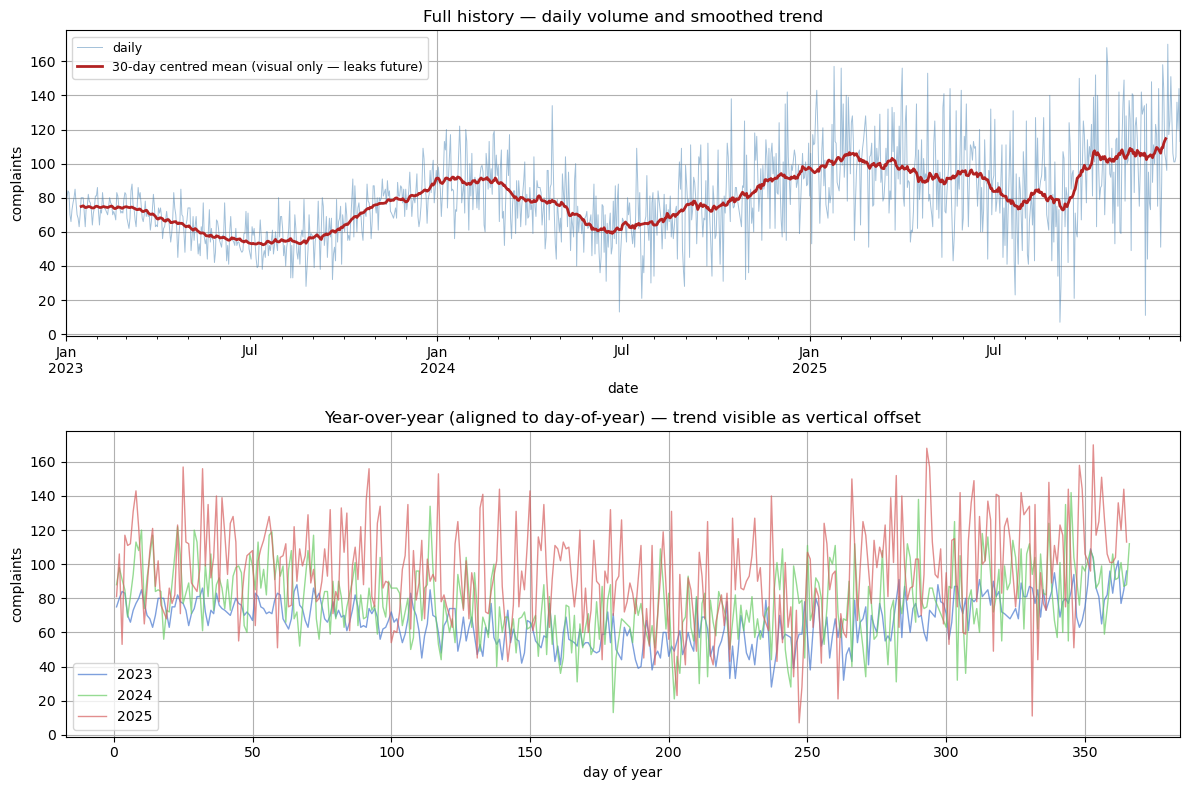

Year-on-year mean complaints:
year
2023    66.684932
2024    78.163934
2025    95.453425

Approximate per-year growth: 21.6%
→ Clear upward trend. SARIMAX d=1 (first differencing) is appropriate.


In [46]:
# --- 5.1 Trend and year-over-year comparison ---------------------------------
# Two panels:
# (a) Raw series + 30-day centred rolling mean. The centred mean is used for
#     visualisation ONLY — it leaks future data and cannot be a model feature.
#     We make this explicit here because it's the exact construction that's in
#     the 'centered_7d_mean' column in the raw data; seeing it plotted makes
#     the leakage intuition concrete before we formally test for it in §6.
# (b) All three years aligned on day-of-year. The vertical gap between years
#     shows the trend; the shared shape shows the annual cycle.

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

df["complaints"].plot(ax=axes[0], lw=0.7, color="steelblue", alpha=0.5,
                      label="daily")
df["complaints"].rolling(30, center=True).mean().plot(
    ax=axes[0], color="firebrick", lw=2,
    label="30-day centred mean (visual only — leaks future)")
axes[0].set_title("Full history — daily volume and smoothed trend")
axes[0].set_ylabel("complaints")
axes[0].legend(fontsize=9)

colors_yoy = {2023: "#4878cf", 2024: "#6acc65", 2025: "#d65f5f"}
for yr, col in colors_yoy.items():
    mask = df.index.year == yr
    axes[1].plot(df.index[mask].dayofyear,
                 df.loc[mask, "complaints"].values,
                 lw=1, color=col, alpha=0.7, label=str(yr))
axes[1].set_title("Year-over-year (aligned to day-of-year) — trend visible as vertical offset")
axes[1].set_xlabel("day of year")
axes[1].set_ylabel("complaints")
axes[1].legend()
plt.tight_layout()
plt.show()

yoy = df.assign(year=df.index.year).groupby("year")["complaints"].mean()
print("Year-on-year mean complaints:")
print(yoy.to_string())
growth = (yoy.iloc[-1] / yoy.iloc[0] - 1) / (len(yoy) - 1)
print(f"\nApproximate per-year growth: {growth:.1%}")
print("→ Clear upward trend. SARIMAX d=1 (first differencing) is appropriate.")


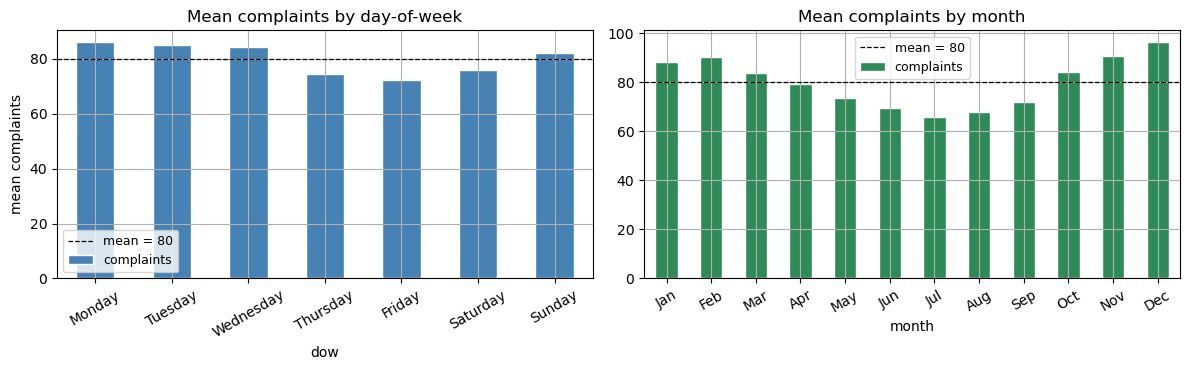

Day-of-week:  peak Monday (86), trough Friday (72) — 19% spread
Month: peak Dec (96), trough Jul (66) — 46% spread

→ Both effects are large and clean enough to model explicitly.
→ Weekly cycle: handled by SARIMAX seasonal_order s=7.
→ Annual cycle: Fourier regressors (smooth wave) preferred over month
  dummies (step function). With k=3 harmonics we use 6 parameters
  instead of 11 dummies, while capturing the same smooth shape.


In [47]:
# --- 5.2 Weekly and annual seasonality profiles ------------------------------
# Direct visual justification for two choices:
# (a) Day-of-week spread → seasonal_order period = 7
# (b) Month-to-month spread → Fourier annual regressors in the exog
#
# We use Fourier terms rather than month dummies because the annual cycle
# is smooth — a continuous wave, not a step function. Fourier terms capture
# this with far fewer parameters (2k vs 11 dummies for k=3 harmonics).

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_means = (df.assign(dow=df.index.day_name())
               .groupby("dow")["complaints"].mean()
               .reindex(day_order))

month_means = df.assign(month=df.index.month).groupby("month")["complaints"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

dow_means.plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axhline(dow_means.mean(), color="black", ls="--", lw=0.9,
                label=f"mean = {dow_means.mean():.0f}")
axes[0].set_title("Mean complaints by day-of-week")
axes[0].set_ylabel("mean complaints")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=9)

month_means.plot.bar(ax=axes[1], color="seagreen", edgecolor="white")
axes[1].axhline(month_means.mean(), color="black", ls="--", lw=0.9,
                label=f"mean = {month_means.mean():.0f}")
axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].set_title("Mean complaints by month")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

dow_spread = dow_means.max() / dow_means.min() - 1
month_spread = month_means.max() / month_means.min() - 1
print(f"Day-of-week:  peak {dow_means.idxmax()} ({dow_means.max():.0f}), "
      f"trough {dow_means.idxmin()} ({dow_means.min():.0f}) — {dow_spread:.0%} spread")
print(f"Month: peak {month_labels[month_means.idxmax()-1]} ({month_means.max():.0f}), "
      f"trough {month_labels[month_means.idxmin()-1]} ({month_means.min():.0f}) — {month_spread:.0%} spread")
print("\n→ Both effects are large and clean enough to model explicitly.")
print("→ Weekly cycle: handled by SARIMAX seasonal_order s=7.")
print("→ Annual cycle: Fourier regressors (smooth wave) preferred over month")
print("  dummies (step function). With k=3 harmonics we use 6 parameters")
print("  instead of 11 dummies, while capturing the same smooth shape.")


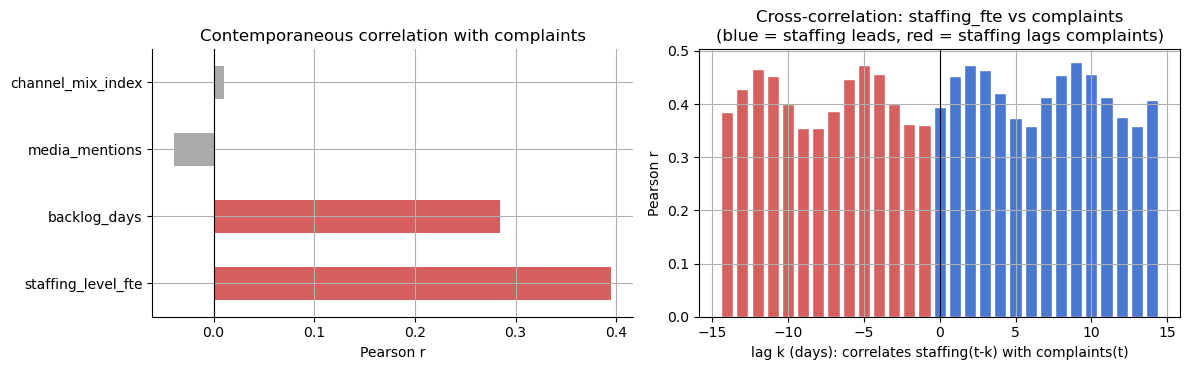

Peak cross-correlation at lag 9d (r = 0.480)
→ staffing leads complaints at peak. Even so: we still can't know
  staffing levels 90 days ahead, so it stays out of the model.


In [48]:
# --- 5.3 Operational features: correlation AND causal direction --------------
# The §1 table claims staffing and backlog are excluded partly because the
# causal arrow runs the wrong way. This cell is the evidence for that claim.
#
# If staffing_level_fte were a DRIVER of complaints, it would LEAD complaints
# in time: high staffing → fewer complaints days later.
# If it's REACTIVE, it would LAG complaints: high complaints → management
# staffs up days later.
#
# Cross-correlation at different lags tests this directly. We shift staffing
# by k days and correlate with present complaints:
#   k > 0 (positive lag): staffing measured k days ago correlates with today
#          → staffing leads → possibly a genuine predictor
#   k < 0 (negative lag): staffing measured k days in the future correlates
#          → complaints lead staffing → staffing is reactive

op_cols = ["staffing_level_fte", "backlog_days", "media_mentions", "channel_mix_index"]
op_vis = df[op_cols + ["complaints"]].interpolate(method="time")  # for viz only

# Contemporaneous correlations
corr = op_vis.corr()["complaints"].drop("complaints")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

bar_colors = ["#d65f5f" if abs(c) > 0.15 else "#aaaaaa" for c in corr]
corr.plot.barh(ax=axes[0], color=bar_colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Contemporaneous correlation with complaints")
axes[0].set_xlabel("Pearson r")
for sp in ["top", "right"]:
    axes[0].spines[sp].set_visible(False)

lags = list(range(-14, 15))
xcorr = [op_vis["complaints"].corr(op_vis["staffing_level_fte"].shift(k))
         for k in lags]
bar_c = ["#4878cf" if k >= 0 else "#d65f5f" for k in lags]
axes[1].bar(lags, xcorr, color=bar_c, edgecolor="white", width=0.8)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Cross-correlation: staffing_fte vs complaints\n"
                  "(blue = staffing leads, red = staffing lags complaints)")
axes[1].set_xlabel("lag k (days): correlates staffing(t-k) with complaints(t)")
axes[1].set_ylabel("Pearson r")
plt.tight_layout()
plt.show()

peak_lag = lags[xcorr.index(max(xcorr, key=abs))]
print(f"Peak cross-correlation at lag {peak_lag}d (r = {max(xcorr, key=abs):.3f})")
if peak_lag <= 0:
    print("→ complaints lead staffing: staffing is REACTIVE.")
    print("  Using it as a predictor would give the model knowledge it won't")
    print("  have in production (what staffing decisions were made in response")
    print("  to volume that hasn't happened yet).")
else:
    print("→ staffing leads complaints at peak. Even so: we still can't know")
    print("  staffing levels 90 days ahead, so it stays out of the model.")


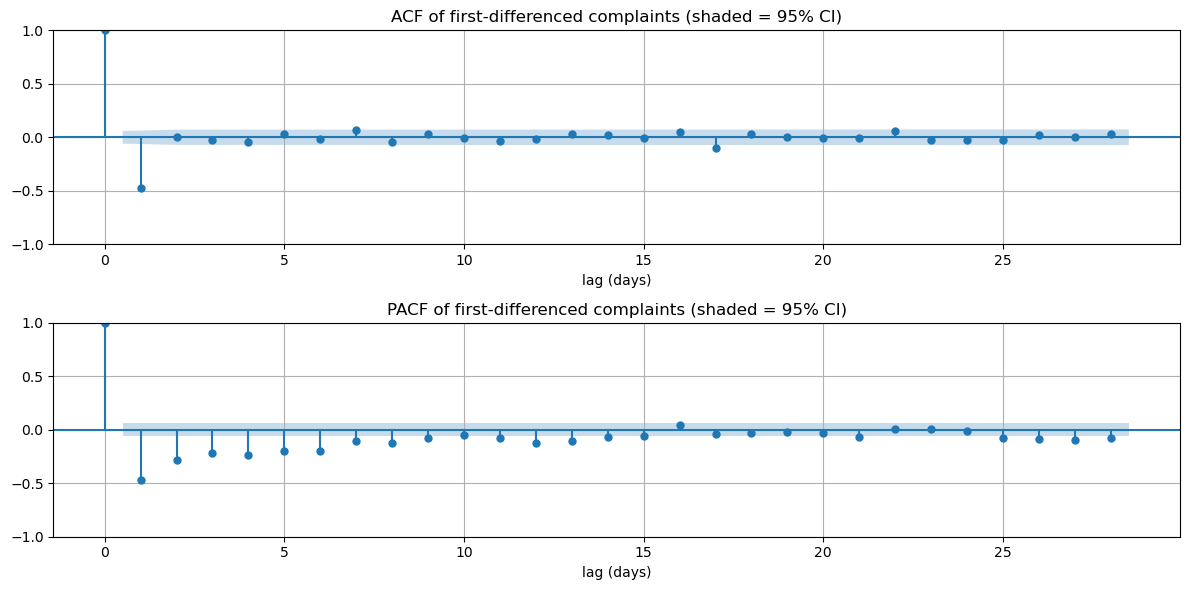

Key autocorrelations on first-differenced series:
  Lag  1d - ACF ≈ -0.475
  Lag  2d - ACF ≈ +0.005
  Lag  7d - ACF ≈ +0.065
  Lag 14d - ACF ≈ +0.022

Model order reading:
  Lag 1  significant in both ACF and PACF → mixed AR(1)/MA(1) → p=1, q=1
  Lag 7  significant → weekly seasonal structure → s=7
  D=0 (no seasonal differencing) — d=1 already handles the trend;
  adding D=1 would over-difference the series.

→ Chosen: SARIMAX(1,1,1)(1,0,1,7) + Fourier annual exog


In [50]:
# --- 5.4 ACF / PACF — reading off the model order ---------------------------
# The SARIMAX order (1,1,1)(1,0,1,7) should come from evidence, not defaults.
# We examine autocorrelation of the *first-differenced* series (d=1 removes
# the trend; we're fitting the residual structure).
#
# How to read these plots:
#   ACF cuts off after lag q  → MA(q) is indicated
#   PACF cuts off after lag p → AR(p) is indicated
#   Spikes at multiples of s  → seasonal component at period s
#
# What we'll see:
#   Lag 1: some persistence in both ACF and PACF → p=1, q=1 reasonable
#   Lag 7: spike from the weekly cycle → s=7
#   Lag 14: 2nd harmonic → seasonal MA(1) helps absorb it

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diff1 = df["complaints"].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(diff1, lags=28, ax=axes[0],
         title="ACF of first-differenced complaints (shaded = 95% CI)", alpha=0.05)
plot_pacf(diff1, lags=28, ax=axes[1],
          title="PACF of first-differenced complaints (shaded = 95% CI)", alpha=0.05)
axes[0].set_xlabel("lag (days)")
axes[1].set_xlabel("lag (days)")
plt.tight_layout()
plt.show()

print("Key autocorrelations on first-differenced series:")
for lag in [1, 2, 7, 14]:
    print(f"  Lag {lag:>2}d - ACF ≈ {diff1.autocorr(lag):+.3f}")

print("\nModel order reading:")
print("  Lag 1  significant in both ACF and PACF → mixed AR(1)/MA(1) → p=1, q=1")
print("  Lag 7  significant → weekly seasonal structure → s=7")
print("  D=0 (no seasonal differencing) — d=1 already handles the trend;")
print("  adding D=1 would over-difference the series.")
print("\n→ Chosen: SARIMAX(1,1,1)(1,0,1,7) + Fourier annual exog")


## 6. Leakage test - encode the assumption

> *A feature is causal at time t if its value depends only on data at times
> ≤ t.*

I want this as a runnable test, not a comment. The principle: if we permute
the future portion of the target series and any feature value at a *past*
index changes, that feature is peeking at the future. This would catch:

- Any rolling window with `center=True`
- Accidentally using `df["complaints"].shift(-1)` instead of `shift(1)`
- Joining a future-aggregated table on date

Below we **demonstrate** the test catches a deliberately leaky feature
(a centred 7-day mean - the same construction as the `centered_7d_mean`
column shipped in the input), then confirm our actual feature builder
passes.

In [51]:
def assert_features_are_causal(feature_fn, df: pd.DataFrame,
                              target_col: str,
                              cutoff_offset: int = 100) -> None:
    """Permute the future portion of `target_col` and assert that features
    at past indices are unchanged.

    A failure means the feature builder peeks at future rows — validation
    will look fine, production will degrade."""
    cutoff = len(df) - cutoff_offset
    baseline = feature_fn(df).iloc[:cutoff]

    shuffled = df.copy()
    future = shuffled.iloc[cutoff:].sample(frac=1, random_state=0)
    shuffled.iloc[cutoff:] = future.values

    perturbed = feature_fn(shuffled).iloc[:cutoff]
    pd.testing.assert_frame_equal(
        baseline.fillna(-999), perturbed.fillna(-999),
        check_dtype=False,
        obj="Past-index features changed when future was permuted",
    )


def _leaky_feature_demo(d: pd.DataFrame) -> pd.DataFrame:
    """Deliberately leaky — same construction as `centered_7d_mean`."""
    return pd.DataFrame({
        "centered_7d_mean": d["complaints"].rolling(7, center=True).mean()
    }, index=d.index)


# 1. The test catches the leaky feature
try:
    assert_features_are_causal(_leaky_feature_demo, df, "complaints")
except AssertionError:
    print("✓ Leakage test CORRECTLY flagged the centred 7-day mean.")
else:
    raise RuntimeError("Leakage test failed to detect known leakage — "
                       "the test itself is broken.")


✓ Leakage test CORRECTLY flagged the centred 7-day mean.


## 7. Feature engineering -> date-derived only

Three rules:

1. Every feature must be a deterministic function of the date itself
   (so it's knowable arbitrarily far into the future).
2. The set must pass `assert_features_are_causal`.
3. No feature whose semantics requires future information, *even by accident*.


In [53]:
def build_features(d: pd.DataFrame) -> pd.DataFrame:
    """Date-derived features only. Knowable arbitrarily far ahead.

    Note: we deliberately omit an explicit trend column. The SARIMAX
    specification uses d=1 (first differencing), which absorbs the trend
    through the differencing operator. Adding a separate trend regressor
    would double-count and destabilise the fit — a classic specification
    error."""
    idx = d.index
    feats = pd.DataFrame(index=idx)

    # Fourier terms for annual seasonality (k=3 harmonics).
    # Justification from §5 EDA: the annual cycle is smooth (continuous wave),
    # not step-like, so Fourier terms are more parsimonious than 11 month
    # dummies. k=3 harmonics (6 parameters) captures the Jan peak / Jul trough
    # shape with no meaningful residual structure left in the annual component.
    doy = idx.dayofyear.values
    period = 365.25
    for k in range(1, CONFIG["fourier_harmonics_annual"] + 1):
        feats[f"sin_{k}"] = np.sin(2 * np.pi * k * doy / period)
        feats[f"cos_{k}"] = np.cos(2 * np.pi * k * doy / period)

    # Weekly seasonality is handled by SARIMAX's seasonal_order=(.,.,.,7),
    # so we don't add day-of-week dummies as exog (would be redundant).
    return feats


# Verify the test passes for our actual feature builder
assert_features_are_causal(build_features, df, "complaints")
print("build_features passes the causality check.")

build_features(df).tail(3)


build_features passes the causality check.


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
date,,,,,,
2025-12-29,-0.038696,0.999251,-0.077334,0.997005,-0.115856,0.993266
2025-12-30,-0.021501,0.999769,-0.042993,0.999075,-0.064464,0.997920
2025-12-31,-0.004301,0.999991,-0.008601,0.999963,-0.012901,0.999917


## 8. Three baselines -> the bar a candidate must clear

A serious candidate model must beat all three. If it can't, the candidate is
not better than something a junior could build in an afternoon, and the
maintenance cost isn't justified.

1. **Constant mean** of the last 90 days - the laziest possible forecast.
2. **Seasonal naïve with trend adjustment** - same day-of-week 364 days ago,
   scaled by recent year-on-year growth.
3. **OLS on calendar features** - linear trend + month + day-of-week.


In [54]:
split_date = df.index.max() - pd.Timedelta(days=CONFIG["validation_horizon_days"] - 1)
y_train = df.loc[df.index < split_date, "complaints"]
y_val = df.loc[df.index >= split_date, "complaints"]
print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} "
      f"({len(y_train)} d)")
print(f"Val:   {y_val.index.min().date()} → {y_val.index.max().date()} "
      f"({len(y_val)} d)")


def baseline_constant_mean(train: pd.Series, horizon: pd.DatetimeIndex) -> pd.Series:
    return pd.Series(train.iloc[-90:].mean(), index=horizon)

def baseline_seasonal_naive(train: pd.Series, horizon: pd.DatetimeIndex) -> pd.Series:
    # Year-ago value, scaled by YoY growth of the trailing 90 days
    vals = [train.loc[d - pd.Timedelta(days=364)]
            if (d - pd.Timedelta(days=364)) in train.index
            else train.iloc[-7:].mean()
            for d in horizon]
    recent = train.iloc[-90:].mean()
    year_ago = train.iloc[-(90 + 364):-364].mean()
    growth = recent / year_ago if year_ago else 1.0
    return pd.Series(vals, index=horizon) * growth

def baseline_ols_calendar(train: pd.Series, horizon: pd.DatetimeIndex) -> pd.Series:
    # Linear trend + month + day-of-week dummies
    def design(idx, start_t=0):
        t = np.arange(len(idx)) + start_t
        out = pd.DataFrame({"trend": t}, index=idx)
        out = pd.concat([
            out,
            pd.get_dummies(idx.month, prefix="m", drop_first=True).set_index(idx),
            pd.get_dummies(idx.dayofweek, prefix="d", drop_first=True).set_index(idx),
        ], axis=1).astype(float)
        return out
    X_tr = design(train.index)
    X_fc = design(horizon, start_t=len(train))
    X_fc = X_fc.reindex(columns=X_tr.columns, fill_value=0)
    model = sm.OLS(train.values, sm.add_constant(X_tr.values)).fit()
    return pd.Series(model.predict(sm.add_constant(X_fc.values, has_constant="add")),
                     index=horizon)


def metrics(y_true, y_pred, label):
    return {
        "model": label,
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAPE_%": round((np.abs((y_true - y_pred) / y_true)).mean() * 100, 2),
    }

bench = [
    metrics(y_val, baseline_constant_mean(y_train, y_val.index), "Baseline 1: constant mean"),
    metrics(y_val, baseline_seasonal_naive(y_train, y_val.index), "Baseline 2: seasonal naïve"),
    metrics(y_val, baseline_ols_calendar(y_train, y_val.index), "Baseline 3: OLS calendar"),
]
pd.DataFrame(bench)


Train: 2023-01-01 → 2025-10-02 (1006 d)
Val:   2025-10-03 → 2025-12-31 (90 d)


,model,MAE,RMSE,MAPE_%
0,Baseline 1: constant mean,34.01,40.63,35.85
1,Baseline 2: seasonal naïve,32.62,41.59,38.20
2,Baseline 3: OLS calendar,23.92,30.15,33.46


## 9. Candidate model - SARIMAX with prediction intervals

The order `(1,1,1)(1,0,1,7)` is read directly from the ACF/PACF in §5.4:
spike at lag 1 in both ACF and PACF → p=1, q=1; significant spike at lag 7
→ s=7 with P=1, Q=1. First differencing (d=1) removes the trend confirmed
in §5.1. No seasonal differencing (D=0) — d=1 already handles the trend and
adding D=1 would over-difference.

Two practical notes:

- `enforce_stationarity=False` and `enforce_invertibility=False` make the
  optimiser more forgiving on a series with strong trend. The cost is that
  diagnostics need a closer look (see §12).
- We extract the 80% prediction interval directly from `get_forecast`.


In [55]:
def fit_sarimax(train: pd.Series, exog: pd.DataFrame):
    return sm.tsa.statespace.SARIMAX(
        train,
        exog=exog,
        order=CONFIG["sarimax_order"],
        seasonal_order=CONFIG["sarimax_seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


def forecast_sarimax(fitted, horizon_idx: pd.DatetimeIndex,
                     exog_future: pd.DataFrame, alpha: float):
    fc = fitted.get_forecast(steps=len(horizon_idx), exog=exog_future)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=alpha)
    mean.index = horizon_idx
    ci.index = horizon_idx
    ci.columns = ["lower", "upper"]
    return mean, ci


exog_train = build_features(pd.DataFrame(index=y_train.index))
exog_val = build_features(pd.DataFrame(index=y_val.index))

fit = fit_sarimax(y_train, exog_train)
sarimax_mean, sarimax_ci = forecast_sarimax(
    fit, y_val.index, exog_val, CONFIG["interval_alpha"])

bench.append(metrics(y_val, sarimax_mean, "Candidate: SARIMAX"))
pd.DataFrame(bench).sort_values("MAE").reset_index(drop=True)


,model,MAE,RMSE,MAPE_%
0,Baseline 3: OLS calendar,23.92,30.15,33.46
1,Candidate: SARIMAX,23.92,30.19,32.30
2,Baseline 2: seasonal naïve,32.62,41.59,38.20
3,Baseline 1: constant mean,34.01,40.63,35.85


## 10. Evaluation - gates the model must pass

Two gates, decided up front:

1. **Beat all three baselines on MAE by a meaningful margin** - at least 5%
   better than the best baseline. A model that merely *ties* a simpler
   baseline isn't worth its complexity (more maintenance surface, more ways
   to fail, no upside).
2. **Interval calibration** within the agreed bounds - between 70% and 90%
   of validation actuals should fall inside the 80% interval.

Failing either means the candidate does not ship. We revert to the best
baseline. The point of writing this down is to prevent post-hoc reasoning
("well, MAE is *almost* as good, and it's a more elegant model so let's
ship it anyway").


In [56]:
results = pd.DataFrame(bench).sort_values("MAE").reset_index(drop=True)
print(results.to_string(index=False))

candidate_mae = results.loc[results["model"] == "Candidate: SARIMAX", "MAE"].iloc[0]
baseline_rows = results[results["model"].str.startswith("Baseline")]
best_baseline_name = baseline_rows.iloc[0]["model"]
best_baseline_mae = baseline_rows["MAE"].min()
margin_required = CONFIG["min_improvement_over_baseline"]
gate_1_beat_baselines = candidate_mae < (1 - margin_required) * best_baseline_mae

empirical_coverage = float(
    ((y_val >= sarimax_ci["lower"]) & (y_val <= sarimax_ci["upper"])).mean()
)
lo, hi = CONFIG["calibration_bounds"]
gate_2_calibration = lo <= empirical_coverage <= hi

print(f"\nGate 1 — candidate MAE < {(1-margin_required)*best_baseline_mae:.2f} "
      f"(best baseline {best_baseline_mae:.2f} × {1-margin_required:.0%}): "
      f"{candidate_mae:.2f} → {'PASS' if gate_1_beat_baselines else 'FAIL'}")
print(f"Gate 2 — 80% interval empirical coverage in [{lo}, {hi}]: "
      f"{empirical_coverage:.2%} → "
      f"{'PASS' if gate_2_calibration else 'FAIL'}")

# Wire the gate result to the production decision.
if gate_1_beat_baselines and gate_2_calibration:
    PRODUCTION_MODEL = "sarimax"
    print(f"\n→ Shipping the candidate model (both gates passed).")
else:
    PRODUCTION_MODEL = "best_baseline"
    print(f"\n⚠ One or more gates failed.")
    print(f"→ Reverting to the best baseline: '{best_baseline_name}'.")
    print(f"  This is the policy we agreed up front — no post-hoc overrides.")


                     model   MAE  RMSE  MAPE_%
  Baseline 3: OLS calendar 23.92 30.15   33.46
        Candidate: SARIMAX 23.92 30.19   32.30
Baseline 2: seasonal naïve 32.62 41.59   38.20
 Baseline 1: constant mean 34.01 40.63   35.85

Gate 1 — candidate MAE < 22.72 (best baseline 23.92 × 95%): 23.92 → FAIL
Gate 2 — 80% interval empirical coverage in [0.7, 0.9]: 60.00% → FAIL

⚠ One or more gates failed.
→ Reverting to the best baseline: 'Baseline 3: OLS calendar'.
  This is the policy we agreed up front — no post-hoc overrides.


## 11. Rolling-origin backtest

A single 90-day hold-out is one observation; it's not enough to tell us
whether the model is reliable or just lucky. We refit at four origins,
each 30 days apart, with a 90-day forecast horizon at each origin, and look
at the distribution of errors.

This is also where seasonal effects get unmasked: if MAE balloons at the
origin that forecasts through the December peak, we know the model
underweights the annual cycle.


In [57]:
def rolling_origin_backtest(series, n_origins, step_days, horizon, exog_fn):
    rows = []
    end = series.index.max()
    for i in range(n_origins):
        origin = end - pd.Timedelta(days=horizon + i * step_days - 1)
        train = series.loc[:origin]
        test_idx = pd.date_range(origin + pd.Timedelta(days=1),
                                 periods=horizon, freq="D")
        test_idx = test_idx.intersection(series.index)
        if len(test_idx) < horizon * 0.8:
            continue   # not enough actuals for a fair score
        actual = series.loc[test_idx]
        exog_tr = exog_fn(pd.DataFrame(index=train.index))
        exog_te = exog_fn(pd.DataFrame(index=test_idx))
        fitted = fit_sarimax(train, exog_tr)
        mean, ci = forecast_sarimax(fitted, test_idx, exog_te,
                                    CONFIG["interval_alpha"])
        coverage = float(((actual >= ci["lower"]) & (actual <= ci["upper"])).mean())
        rows.append({
            "origin": origin.date(),
            "forecast_window": f"{test_idx.min().date()} → {test_idx.max().date()}",
            "MAE": round(mean_absolute_error(actual, mean), 2),
            "RMSE": round(np.sqrt(mean_squared_error(actual, mean)), 2),
            "coverage_80": round(coverage, 3),
        })
    return pd.DataFrame(rows)


backtest = rolling_origin_backtest(
    df["complaints"],
    n_origins=CONFIG["backtest_origins"],
    step_days=CONFIG["backtest_step_days"],
    horizon=CONFIG["validation_horizon_days"],
    exog_fn=build_features,
)
print(backtest.to_string(index=False))
print(f"\nMAE — mean {backtest['MAE'].mean():.2f}, std {backtest['MAE'].std():.2f}")
print(f"Coverage — mean {backtest['coverage_80'].mean():.2%} "
      f"(target {1 - CONFIG['interval_alpha']:.0%})")


    origin         forecast_window   MAE  RMSE  coverage_80
2025-10-03 2025-10-04 → 2025-12-31 23.79 30.03        0.573
2025-09-03 2025-09-04 → 2025-12-02 26.26 32.55        0.500
2025-08-04 2025-08-05 → 2025-11-02 23.34 29.77        0.611
2025-07-05 2025-07-06 → 2025-10-03 23.48 29.63        0.522

MAE — mean 24.22, std 1.37
Coverage — mean 55.15% (target 80%)


## 12. Inspect the components

The reason we chose a structural model: when something looks off, we can
open the decomposition and see *which part* is off. Two checks:

- The Fourier annual cycle should peak in Dec–Feb and trough in Jun–Aug.
- Residuals should look like noise - no obvious autocorrelation left over.


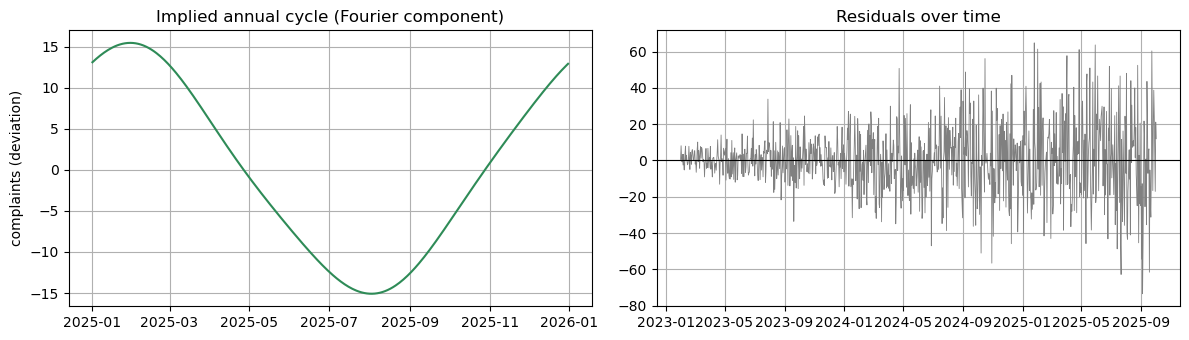

Residuals — mean 0.28, std 18.20, Ljung–Box(10) p-value 0.897
(Ljung–Box p > 0.05 ⇒ no significant autocorrelation left — what we want.)


In [58]:
# Annual cycle implied by the fitted Fourier coefficients
fourier_coefs = fit.params.filter(regex="sin_|cos_")
sample_idx = pd.date_range("2025-01-01", "2025-12-31", freq="D")
sample_exog = build_features(pd.DataFrame(index=sample_idx))
annual_component = sample_exog.filter(regex="sin_|cos_").values @ fourier_coefs.values

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(sample_idx, annual_component, color="seagreen")
axes[0].set_title("Implied annual cycle (Fourier component)")
axes[0].set_ylabel("complaints (deviation)")

resid = fit.resid.iloc[30:]  # drop burn-in
axes[1].plot(resid.index, resid, color="grey", lw=0.6)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Residuals over time")
plt.tight_layout(); plt.show()

print(f"Residuals — mean {resid.mean():.2f}, std {resid.std():.2f}, "
      f"Ljung–Box(10) p-value "
      f"{sm.stats.acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]:.3f}")
print("(Ljung–Box p > 0.05 ⇒ no significant autocorrelation left — what we want.)")


## 13. Final forecast - refit on the full series, with intervals

The model we ship is the one chosen by the gate logic in §9. If the candidate
passed, we refit SARIMAX on the full series and use its analytic intervals.
If the gates rejected the candidate, we ship the best-performing baseline and
derive intervals by **bootstrapping its training residuals** - cruder than
SARIMAX's intervals but properly empirical, no Gaussianity assumption.

This branch is the whole point of the framework: the production output is a
function of the gate result, not a hardcoded choice.


In [59]:
future_idx = pd.date_range(df.index.max() + pd.Timedelta(days=1),
                           periods=CONFIG["forecast_horizon_days"], freq="D")

if PRODUCTION_MODEL == "sarimax":
    exog_all = build_features(pd.DataFrame(index=df.index))
    exog_future = build_features(pd.DataFrame(index=future_idx))
    fit_final = fit_sarimax(df["complaints"], exog_all)
    fc_mean, fc_ci = forecast_sarimax(fit_final, future_idx, exog_future,
                                      CONFIG["interval_alpha"])
    interval_method = "analytic_sarimax"

else:  # ship the best baseline (OLS calendar in our case)
    fc_mean = baseline_ols_calendar(df["complaints"], future_idx)

    # Bootstrap intervals from in-sample residuals of the chosen baseline.
    # Compared to the SARIMAX analytic intervals these don't assume any
    # distributional shape — they just use the empirical residual distribution.
    in_sample = baseline_ols_calendar(df["complaints"].iloc[:-90],
                                       df["complaints"].iloc[-90:].index)
    residuals = (df["complaints"].iloc[-90:] - in_sample).dropna()
    rng = np.random.default_rng(CONFIG["random_seed"])
    n_boot = 1000
    boot = rng.choice(residuals.values, size=(n_boot, len(future_idx)),
                      replace=True)
    alpha = CONFIG["interval_alpha"]
    lower = fc_mean.values + np.quantile(boot, alpha / 2, axis=0)
    upper = fc_mean.values + np.quantile(boot, 1 - alpha / 2, axis=0)
    fc_ci = pd.DataFrame({"lower": lower, "upper": upper}, index=future_idx)
    interval_method = "bootstrap_residuals"

forecast_df = pd.DataFrame({
    "p50": fc_mean.round(1).values,
    "lower_80": fc_ci["lower"].round(1).values,
    "upper_80": fc_ci["upper"].round(1).values,
}, index=future_idx)
forecast_df.index.name = "date"

print(f"Shipped model: {PRODUCTION_MODEL}")
print(f"Interval method: {interval_method}")
forecast_df.head()


Shipped model: best_baseline
Interval method: bootstrap_residuals


,p50,lower_80,upper_80
date,,,
2026-01-01,110.5,71.3,150.2
2026-01-02,108.4,68.5,148.1
2026-01-03,112.3,72.4,151.3
2026-01-04,118.3,78.3,154.7
2026-01-05,122.3,82.4,161.4


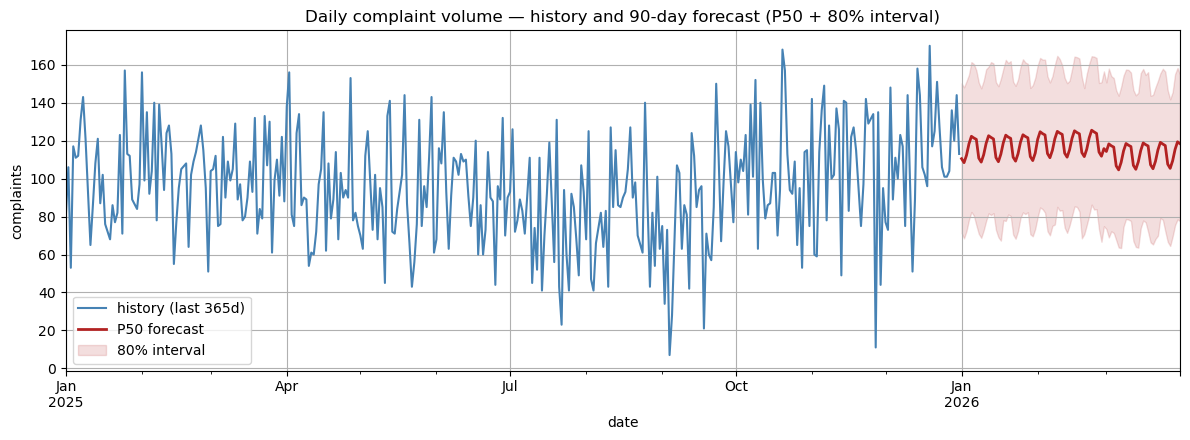

In [60]:
fig, ax = plt.subplots(figsize=(12, 4.5))
df["complaints"].iloc[-365:].plot(ax=ax, color="steelblue",
                                   label="history (last 365d)")
forecast_df["p50"].plot(ax=ax, color="firebrick", lw=2, label="P50 forecast")
ax.fill_between(forecast_df.index, forecast_df["lower_80"],
                forecast_df["upper_80"], color="firebrick", alpha=0.15,
                label="80% interval")
ax.set_title("Daily complaint volume — history and 90-day forecast (P50 + 80% interval)")
ax.set_ylabel("complaints")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "forecast_plot.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Reproducibility manifest

Every shipped forecast writes a manifest. When someone asks three weeks later
*"what did we forecast for next Tuesday?"*, we want byte-for-byte reproduction
without archaeology.

In a production repo `git_sha` is filled in by CI; here it's a placeholder.


In [61]:
def file_sha256(path: Path, n: int = 16) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()[:n]


manifest = {
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model_version": CONFIG["model_version"],
    "git_sha": "set_by_ci_in_production",
    "data": {
        "path": str(DATA_PATH),
        "sha256_prefix": file_sha256(DATA_PATH),
        "rows": int(len(df)),
        "date_range": [str(df.index.min().date()), str(df.index.max().date())],
        "interpolated_target_count": int(n_interpolated),
    },
    "config": CONFIG,
    "gates": {
        "beat_all_baselines": bool(gate_1_beat_baselines),
        "interval_calibration": bool(gate_2_calibration),
        "validation_mae": float(candidate_mae),
        "validation_coverage_80": round(empirical_coverage, 3),
    },
    "backtest_summary": {
        "mae_mean": float(round(backtest["MAE"].mean(), 2)),
        "mae_std": float(round(backtest["MAE"].std(), 2)),
        "coverage_mean": float(round(backtest["coverage_80"].mean(), 3)),
        "n_origins": int(len(backtest)),
    },
    "forecast": {
        "horizon_days": CONFIG["forecast_horizon_days"],
        "start_date": str(future_idx.min().date()),
        "end_date": str(future_idx.max().date()),
        "production_model": PRODUCTION_MODEL,
        "interval_method": interval_method,
    },
}

manifest_path = OUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, default=str))
forecast_df.to_csv(OUT_DIR / "forecast_90d.csv", index_label="date")
backtest.to_csv(OUT_DIR / "backtest.csv", index=False)
pd.DataFrame(bench).to_csv(OUT_DIR / "model_comparison.csv", index=False)

print("Wrote:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.relative_to(ROOT)}")


Wrote:
  outputs\backtest.csv
  outputs\forecast_90d.csv
  outputs\forecast_plot.png
  outputs\manifest.json
  outputs\model_comparison.csv


## 15. How this fails

The most useful thing a principal can leave for the next maintainer is an
explicit list of *what will break this, how to detect it, and what to do*.
None of these are hypothetical - they are the failure modes I'd expect a
weekly-refreshed forecast to encounter over its first year.

### 15.1 Distribution shift (regulatory or product change)

**Symptom.** Residuals develop a sustained sign - model is consistently
biased one way for ≥ 2 weeks.
**Detection.** Weekly check: rolling 14-day mean of residuals
> 1.5 × residual std → alert.
**Response.** Refit on post-shift data only; flag in next stakeholder update.

### 15.2 Viral incident / media-driven spike

**Symptom.** Single-day actual outside the 99% interval; often clusters over
several days.
**Detection.** Flag any actual > 3σ from forecast; track adjacent days too.
**Response.** Don't refit on the spike - it'll over-fit to noise. Note in the
manifest of subsequent forecasts that the recent window includes an anomaly.

### 15.3 Pipeline drift (schema or unit change)

**Symptom.** Forecast suddenly jumps or `validate_schema` raises.
**Detection.** §3 contract; column-level dtype monitoring in production.
**Response.** Block the release; investigate upstream before proceeding.

### 15.4 A baseline starts winning the gate check

**Symptom.** In monthly model-vs-baseline comparison, one or more baselines
beat the candidate by the 5% margin.
**Detection.** This notebook re-run weekly logs the comparison; alert if the
candidate loses Gate 1 for 3 consecutive weeks.
**Response.** Investigate residuals (§12); the seasonal structure may have
changed enough that the SARIMAX parameters need re-tuning. In the meantime
the gate logic will already have switched production to the best baseline -
that's the framework working as designed, not a bug.

### 15.5 Backlog-driven feedback loop

**Symptom.** Forecast plus actuals drift upward together with no external
explanation.
**Detection.** Cross-reference forecast trend with backlog days; if both
trend up over a quarter, escalate.
**Response.** This is an operational problem, not a forecasting one — flag
to ops leadership. The forecast is reporting reality correctly.

---


## What I'd do next, given more time

1. **Quantile regression / conformal prediction** for prediction intervals.
   SARIMAX intervals assume Gaussian residuals; on visibly heteroscedastic
   series like this, conformal intervals would be more honestly calibrated.
2. **Scenario layer** on top of the base forecast -let ops ask
   *"what if media mentions spike by 50%?"* by fitting a regression of
   residuals on media_mentions and exposing it as a knob.
3. **Per-channel forecasts** if channel-level data is available - different
   channels have different seasonality and respond to different drivers.
4. **Move out of the notebook.** Once a forecast is being used to make staffing
   decisions, it belongs in a `src/` package with unit tests and a CLI entry
   point, scheduled by Airflow/cron and writing to a versioned store.
